# Face Alignment

## Выбор датасета

В этом проекте мы будем работать с датасетом [CelebA - Original Wild Images](https://www.kaggle.com/datasets/kevinpatel04/celeba-original-wild-images). Обычно, когда говорят про CelebA имеют ввиду его кропнутую и выровненную версию, но мы будем работать с сырой.

![CelebA](https://figures.semanticscholar.org/7df4f96138a4e23492ea96cf921794fc5287ba72/6-Figure4-1.png)

Оригинальная версия датасета весит очень много: ~20 гб. Все картинки нам не будут нужны, достаточно будет ограничиться 10.000+.

Вашим первым заданием будет подготовить себе рабочий датасет. Он будет использован и в следующих заданиях, поэтому подойдите к этому очень ответственно:

- Скачайте себе датасет CelebA In a Wild любым удобным способом;
- Подумайте над тем, по каким критериям лучше всего выбирать картинки. Используйте файл с атрибутами. Обоснуйте свой выбор текстом. В случае, если обоснования выбора датасета не будет, то баллы могут быть снижены. Отнеситесь к этому серьезно: хорошая подготовка данных очень важна;
- Отберите 10.000+ изображений. Можно и больше при желании;
- При помощи атрибутов bbox'а, обрежьте картинки, чтобы на них остались только лица. При желании можно делать дополнительный кроп, так как не везде разметка идеальна, но не нужно сидеть над каждой картинкой отдельно - потратите слишком много времени;
- Сохраните отдельный csv-файл с оригинальными названиями изображений, которые были отобраны в ваш датасет. В дальнейшем он в том числе понадобится для сдачи проекта.

Несколько практических советов:
- Если решили делать дополнительный кроп изображений самостоятельно, то имейте ввиду, что ключевые точки лица в атрибутах указаны в начальной системе координат.
- Не работайте с датасетом в колабе. Простейшую работу с файлами удобнее всего делать локально на своем компьютере. Это не требует мощного железа и скачивания библиотек. Если все же пользуетесь колабом, то работайте на CPU, чтобы не лишний раз не тратить токены.
- Если есть возможность, то не удаляйте оригинальный датасет с вашего компьютера на период работы над проектом. Да, это лишняя занятая память, но зато при надобности можно будет быстро что-то изменить.
- Загрузите финальный датасет (10.000+ картинок) себе на Google Disk. Это удобнее, чем каждый раз отдельно загружать его себе в колаб сессию.

## Собираем датасет

In [ ]:
import kagglehub

path = kagglehub.dataset_download("kevinpatel04/celeba-original-wild-images")

print("Path to dataset files:", path)

Resuming download from 3265265664 bytes (15299851735 bytes left)...
Resuming download from https://www.kaggle.com/api/v1/datasets/download/kevinpatel04/celeba-original-wild-images?dataset_version_number=1 (3265265664/18565117399) bytes left.


100%|██████████| 17.3G/17.3G [02:06<00:00, 121MB/s]


Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/kevinpatel04/celeba-original-wild-images/versions/1


In [ ]:
import os

dataset_path = "/root/.cache/kagglehub/datasets/kevinpatel04/celeba-original-wild-images/versions/1"


# Проверим, существует ли сам dataset_path
print("Путь существует:", os.path.exists(dataset_path))

# Выведем все содержимое (включая скрытые файлы)
print("\nСодержимое dataset_path:")
try:
    for item in os.listdir(dataset_path):
        item_path = os.path.join(dataset_path, item)
        is_dir = os.path.isdir(item_path)
        size = os.path.getsize(item_path)
        print(f"  {item} [{'директория' if is_dir else 'файл'}, {size} байт]")
except Exception as e:
    print("Ошибка при чтении содержимого:", e)

# 3. Проверим наличие хотя бы одного Part-каталога
print("\nПроверка конкретных Part-папок:")
for i in range(1, 6):  # Проверим первые 5
    part_path = os.path.join(dataset_path, f"Part {i}")
    exists = os.path.exists(part_path)
    is_dir = os.path.isdir(part_path)
    print(f"Part {i}: существует={exists}, это директория={is_dir}")

Путь существует: True

Содержимое dataset_path:
  Part 1 [директория, 4096 байт]
  Part 2 [директория, 4096 байт]
  list_landmarks_align_celeba.csv [файл, 9932092 байт]
  Part 13 [директория, 4096 байт]
  Part 5 [директория, 4096 байт]
  list_attr_celeba.csv [файл, 24913339 байт]
  list_eval_partition.csv [файл, 2836404 байт]
  Part 18 [директория, 4096 байт]
  Part 12 [директория, 4096 байт]
  Part 6 [директория, 4096 байт]
  list_bbox_celeba.csv [файл, 5390926 байт]
  Part 8 [директория, 4096 байт]
  Part 19 [директория, 4096 байт]
  Part 3 [директория, 4096 байт]
  Part 11 [директория, 4096 байт]
  Part 15 [директория, 4096 байт]
  Part 20 [директория, 4096 байт]
  Part 4 [директория, 4096 байт]
  Part 17 [директория, 4096 байт]
  Part 21 [директория, 4096 байт]
  Part 9 [директория, 4096 байт]
  Part 7 [директория, 4096 байт]
  Part 16 [директория, 4096 байт]
  Part 14 [директория, 4096 байт]
  Part 10 [директория, 4096 байт]

Проверка конкретных Part-папок:
Part 1: существует=True

In [ ]:
import pandas as pd

# Загружаем CSV-файлы
attrs = pd.read_csv(f"{dataset_path}/list_attr_celeba.csv")
bbox = pd.read_csv(f"{dataset_path}/list_bbox_celeba.csv")
#partition = pd.read_csv(f"{dataset_path}/list_eval_partition.csv")  # этот файл не понадобится, делить нужно самостоятельно
#landmarks = pd.read_csv(f"{dataset_path}/list_landmarks_align_celeba.csv") #нужно скачать точки с сайта авторов датасета, а не с kaggle

# Приводим к единому формату
if 'image_id' not in attrs.columns:
    attrs = attrs.rename(columns={attrs.columns[0]: 'image_id'})

In [ ]:
# Склеиваем данные по image_id
data = bbox.merge(attrs, on='image_id')

print(f"Всего изображений в метаданных: {len(data)}")

Всего изображений в метаданных: 202599


In [ ]:
print("Столбцы в bbox:", bbox.columns.tolist())
print("\nПервые строки bbox:")
display(bbox.head())

Столбцы в bbox: ['image_id', 'x_1', 'y_1', 'width', 'height']

Первые строки bbox:


,image_id,x_1,y_1,width,height
0,000001.jpg,95,71,226,313
1,000002.jpg,72,94,221,306
2,000003.jpg,216,59,91,126
3,000004.jpg,622,257,564,781
4,000005.jpg,236,109,120,166


In [ ]:
print("Столбцы в attrs:", attrs.columns.tolist())
print("\nПервые строки attrs:")
display(attrs.head())

Столбцы в attrs: ['image_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace', 'Wearing_Necktie', 'Young']

Первые строки attrs:


,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1


In [ ]:
file_path_pers_id = "/content/identity_CelebA.txt"
file_path_landmarks = "/content/list_landmarks_celeba.txt"
# Читаем: пробелы/табы как разделитель, без заголовка
person_id = pd.read_csv(file_path_pers_id, sep=r'\s+', header=None, names=['image_id', 'person_id'])

# Читаем все строки файла landmarks
with open(file_path_landmarks, 'r') as f:
    lines = f.readlines()

# Удаляем пустые строки и лишние пробелы
lines = [line.strip() for line in lines if line.strip()]

# Первая строка — число (пропускаем)
# Вторая строка — заголовки столбцов (добавим 'image_id' вручную)
header = ['image_id'] + lines[1].split()

# Остальные строки — данные
data_lines = lines[2:]

# Разбиваем каждую строку на поля (по пробелам)
data = []
for line in data_lines:
    parts = line.split()
    # Первый элемент — image_id, остальные — координаты
    image_id = parts[0]
    coords = list(map(float, parts[1:]))  # преобразуем в числа
    data.append([image_id] + coords)

# Создаём DataFrame
landmarks = pd.DataFrame(data, columns=header)

display(person_id.head())
display(landmarks.head())


,image_id,person_id
0,000001.jpg,2880
1,000002.jpg,2937
2,000003.jpg,8692
3,000004.jpg,5805
4,000005.jpg,9295


,image_id,lefteye_x,lefteye_y,righteye_x,righteye_y,nose_x,nose_y,leftmouth_x,leftmouth_y,rightmouth_x,rightmouth_y
0,000001.jpg,165.0,184.0,244.0,176.0,196.0,249.0,194.0,271.0,266.0,260.0
1,000002.jpg,140.0,204.0,220.0,204.0,168.0,254.0,146.0,289.0,226.0,289.0
2,000003.jpg,244.0,104.0,264.0,105.0,263.0,121.0,235.0,134.0,251.0,140.0
3,000004.jpg,796.0,539.0,984.0,539.0,930.0,687.0,762.0,756.0,915.0,756.0
4,000005.jpg,273.0,169.0,328.0,161.0,298.0,172.0,283.0,208.0,323.0,207.0


Посмотрим, сколько у нас персон с более, чем 10. изображениями (это минимум для обучения)

In [ ]:
import random
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Группируем по person_id, считаем число изображений
person_counts = person_id['person_id'].value_counts()
valid_persons = person_counts[person_counts >= 10].index.tolist()
print(f"Персон с ≥10 изображениями: {len(valid_persons)}")

# Выбираем 3 случайные персоны из подходящих
selected_persons = random.sample(valid_persons, 3)
print("Выбранные персоны:", selected_persons)

Персон с ≥5 изображениями: 8369
Выбранные персоны: [7190, 6565, 8868]


Создадим небольшой словарик для вывода по 5 картинок к персоне для визуализации

In [ ]:
dataset_path = "/root/.cache/kagglehub/datasets/kevinpatel04/celeba-original-wild-images/versions/1"

# Создаем словарь: персона ключ к списку путей к изображениям
images_to_show = {}

for person in selected_persons:
    # Находим все изображения этой персоны
    person_images = person_id[person_id['person_id'] == person]['image_id'].tolist()

    # Выбираем 5 случайных
    selected_images = random.sample(person_images, 5)

    images_to_show[person] = selected_images

Напишем функцию для поиска путей к картинкам:

In [ ]:
def find_image_path(img_name, base_path):
    """Ищет изображение в подпапках Part X"""
    for root, dirs, files in os.walk(base_path):
        if img_name in files:
            return os.path.join(root, img_name)
    return None  # если не найдено

# Собираем полные пути
full_paths = {}
for person, img_list in images_to_show.items():
    full_paths[person] = []
    for img_name in img_list:
        path = find_image_path(img_name, dataset_path)
        if path:
            full_paths[person].append(path)
        else:
            print(f"Изображение не найдено: {img_name}")

Визуализируем, что у нас вышло, 3 рандомные персоны о 5 картинок к каждой

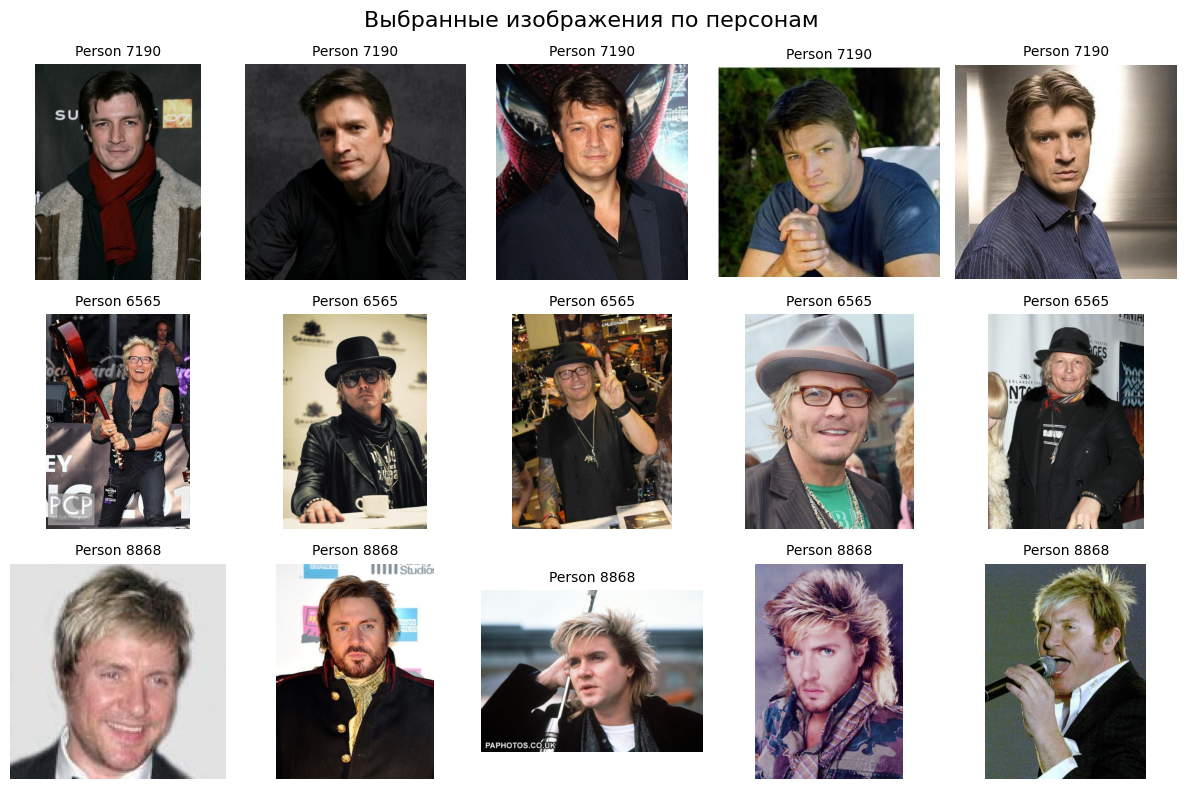

In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(12, 8))
fig.suptitle("Выбранные изображения по персонам", fontsize=16)

for i, person in enumerate(selected_persons):
    for j, img_path in enumerate(full_paths[person]):
        ax = axes[i, j]
        try:
            img = plt.imread(img_path)
            ax.imshow(img)
            ax.set_title(f"Person {person}", fontsize=10)
            ax.axis('off')
        except Exception as e:
            ax.text(0.5, 0.5, "Ошибка загрузки", ha='center', va='center')
            ax.axis('off')

plt.tight_layout()
plt.show()

Получилось! Теперь отберем отсюда около 10 тысяч фото

### Фильтрация изображений

Проверим дубли:

In [ ]:
print(len(person_id))
print(person_id.duplicated().sum())
print(person_id['image_id'].duplicated().sum())

202599
0
0


Идея фильтрации датасета в том, чтобы выбрать те персоны, у которых есть по 30 фото на персону. Далее, пыталась уравновесить датасет по полу и возрасту. Когда выяснилось, что даже по полу конфликт, и есть 172 конфликтные по полу персоны, их убрала из рассмотрения.
После баланса датасета убрала персон с размытыми фото.

In [ ]:
from pathlib import Path

dataset_path = "/root/.cache/kagglehub/datasets/kevinpatel04/celeba-original-wild-images/versions/1"

# Ищем все изображения с расширениями .jpg, .jpeg, .png
image_extensions = [".jpg", ".jpeg", ".png"]
all_image_paths = []

for ext in image_extensions:
    all_image_paths.extend(Path(dataset_path).rglob(f"*{ext}"))

print(f"Найдено изображений: {len(all_image_paths)}")

Найдено изображений: 202599


In [ ]:
import numpy as np

In [ ]:
# Данные
dataset_path = "/root/.cache/kagglehub/datasets/kevinpatel04/celeba-original-wild-images/versions/1"
data = person_id.merge(attrs, on='image_id', how='inner')

# Ищем все изображения в датасете (рекурсивно)
image_extensions = [".jpg", ".jpeg", ".png"]
all_image_paths = []

for ext in image_extensions:
    all_image_paths.extend(Path(dataset_path).rglob(f"*{ext}"))

print(f"Найдено изображений на диске: {len(all_image_paths)}")

# Создаем DataFrame с путями
df_images = pd.DataFrame({
    "image_id": [p.name for p in all_image_paths],
    "image_path": [str(p) for p in all_image_paths]
})

# Объединяем с data по image_id
df = data.merge(df_images, on="image_id", how="inner")

print(f"Совпадений image_id: {len(df)}")
if len(df) < len(data):
    print(f"Внимание: не найдены пути для {len(data) - len(df)} изображений!")

Найдено изображений на диске: 202599
Совпадений image_id: 202599


In [ ]:
# Считаем число фото на персону (техническая ячейка, проверяем здесь у скольки более 5, более 10 и тд)
person_counts = data['person_id'].value_counts()
valid_persons = person_counts[person_counts >= 30].index
valid_persons.value_counts().sum()

np.int64(2360)

К этому моменту стало ясно, что можно смело брать персон с 30 фото, и для обучения 10 000 картинок при этом наберется.

In [ ]:
# Фильтруем, оставляя персоны с ≥30 фото
person_counts = df["person_id"].value_counts()
selected_persons = person_counts[person_counts >= 30].index

df_filtered = df[df["person_id"].isin(selected_persons)].reset_index(drop=True)
print(f"Персон с ≥30 фото: {len(selected_persons)}")
print(f"Изображения после фильтрации по количеству: {len(df_filtered)}")

Персон с ≥30 фото: 2360
Изображения после фильтрации по количеству: 70838


In [ ]:
df.columns

Index(['image_id', 'person_id', '5_o_Clock_Shadow', 'Arched_Eyebrows',
       'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips',
       'Big_Nose', 'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair',
       'Bushy_Eyebrows', 'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee',
       'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones', 'Male',
       'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard',
       'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline',
       'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair',
       'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick',
       'Wearing_Necklace', 'Wearing_Necktie', 'Young', 'image_path'],
      dtype='object')

In [ ]:
Напишем небольшо йанализ распределения признаков

In [ ]:
# Служебные колонки (не анализируем)
SERVICE_COLS = ['image_id', 'person_id', 'image_path']

# Все атрибутные колонки
ATTRIBUTE_COLS = [
    col for col in df_filtered.columns if col not in SERVICE_COLS
]

# Смысловые группы
GROUPS = {
    'Пол и возраст': ['Male', 'Young'],

    'Волосы и борода': [
        'Bald', 'Bangs', 'Black_Hair', 'Blond_Hair', 'Brown_Hair',
        'Gray_Hair', 'Receding_Hairline', 'Sideburns', 'Goatee', 'Mustache',
        'No_Beard'
    ],

    'Черты лица': [
        '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Bags_Under_Eyes',
        'Big_Lips', 'Big_Nose', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin',
        'High_Cheekbones', 'Narrow_Eyes', 'Oval_Face', 'Pointy_Nose',
        'Pale_Skin', 'Rosy_Cheeks'
    ],

    'Аксессуары и макияж': [
        'Eyeglasses', 'Heavy_Makeup', 'Wearing_Earrings',
        'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace',
        'Wearing_Necktie'
    ],

    'Выражение лица': ['Smiling', 'Mouth_Slightly_Open'],

    'Качество изображения': ['Blurry']
}

In [ ]:
def analyze_group(df, cols, group_name):
    """
    Анализирует группу атрибутов: считает количество и долю значений =1.
    Возвращает DataFrame с результатами.
    """
    # Отбираем только существующие в датасете колонки
    existing_cols = [col for col in cols if col in df.columns]
    if not existing_cols:
        return None

    counts = (df[existing_cols] == 1).sum()
    percents = (counts / len(df)) * 100

    result = pd.DataFrame({
        'Атрибут': existing_cols,
        'Количество (1)': counts.values,
        'Доля (%)': percents.round(1).values
    })
    result['Группа'] = group_name
    return result

In [ ]:
print(f"Всего изображений: {len(df_filtered)}\n")

all_results = []  # Для сбора всех результатов

for group_name, cols in GROUPS.items():
    result_df = analyze_group(df_filtered, cols, group_name)
    if result_df is not None:
        #print(f"=== {group_name} ===")
        #print(result_df.to_string(index=False))
        #print()  # Пустая строка между группами
        all_results.append(result_df)

# Собираем все результаты в одну таблицу
if all_results:
    full_report = pd.concat(all_results, ignore_index=True)
else:
    full_report = pd.DataFrame()
display(full_report)

Всего изображений: 70838



,Атрибут,Количество (1),Доля (%),Группа
0,Male,23551,33.2,Пол и возраст
1,Young,57576,81.3,Пол и возраст
2,Bald,1017,1.4,Волосы и борода
3,Bangs,12895,18.2,Волосы и борода
4,Black_Hair,16106,22.7,Волосы и борода
5,Blond_Hair,12156,17.2,Волосы и борода
6,Brown_Hair,14343,20.2,Волосы и борода
7,Gray_Hair,1552,2.2,Волосы и борода
8,Receding_Hairline,4624,6.5,Волосы и борода
9,Sideburns,4513,6.4,Волосы и борода


In [ ]:
df_filtered['image_id'].duplicated().sum()

np.int64(0)

Начинаем балансировать по полу.

In [ ]:
print("Исходные данные:")
print(f"Всего изображений: {len(df_filtered)}")

# Разделяем персон по полу
men_data = df_filtered[df_filtered['Male'] == 1]      # Мужчины (Male = 1)
women_data = df_filtered[df_filtered['Male'] == -1]   # Женщины (Male = -1)

# Получаем уникальные ID персон
men_ids = men_data['person_id'].unique()
women_ids = women_data['person_id'].unique()


print(f"\nЧисло персон:")
print(f"  Мужчины: {len(men_ids)}")
print(f"  Женщины: {len(women_ids)}")


# Определяем, какой пол представлен меньше
if len(men_ids) <= len(women_ids):
    target_n = len(men_ids)
    # Берём всех мужчин, из женщин делаем подвыборку
    sampled_men_ids = men_ids
    sampled_women_ids = pd.Series(women_ids).sample(
        n=target_n, random_state=42, replace=False
    ).values
    print(f"\nБалансируем: все мужчины + {target_n} случайно выбранных женщин")
else:
    target_n = len(women_ids)
    # Берём всех женщин, из мужчин делаем подвыборку
    sampled_women_ids = women_ids
    sampled_men_ids = pd.Series(men_ids).sample(
        n=target_n, random_state=42, replace=False
    ).values
    print(f"\nБалансируем: все женщины + {target_n} случайно выбранных мужчин")


# Берём ВСЕ фото выбранных персон
men_sample = df_filtered[df_filtered['person_id'].isin(sampled_men_ids)]
women_sample = df_filtered[df_filtered['person_id'].isin(sampled_women_ids)]


# Объединяем
balanced_df = pd.concat([men_sample, women_sample], axis=0, ignore_index=True)


# Итоговые статистики
total_photos = len(balanced_df)
total_persons = len(sampled_men_ids) + len(sampled_women_ids)


print(f"\n=== Результат балансировки ===")
print(f"Всего фото в сбалансированном датасете: {total_photos}")
print(f"Всего персон: {total_persons} (из них:")
print(f"  мужчин: {len(sampled_men_ids)}")
print(f"  женщин: {len(sampled_women_ids)})")


print(f"\nРаспределение фото по полу:")
print(balanced_df['Male'].value_counts())
print(balanced_df['Male'].value_counts(normalize=True).round(3))


# Сохраняем результат
balanced_df.to_csv('balanced_by_gender.csv', index=False)
print("\nСбалансированный датасет сохранён в 'balanced_by_gender.csv'")


Исходные данные:
Всего изображений: 70838

Число персон:
  Мужчины: 991
  Женщины: 1646

Балансируем: все мужчины + 991 случайно выбранных женщин

=== Результат балансировки ===
Всего фото в сбалансированном датасете: 59489
Всего персон: 1982 (из них:
  мужчин: 991
  женщин: 991)

Распределение фото по полу:
Male
-1    34617
 1    24872
Name: count, dtype: int64
Male
-1    0.582
 1    0.418
Name: proportion, dtype: float64

Сбалансированный датасет сохранён в 'balanced_by_gender.csv'


In [ ]:
balanced_df['image_id'].duplicated().sum()

np.int64(5160)

Вот тут выясняется, что есть неопределенные по полу персоны. Возможно, это был гендерный переход, в любом случае мы их брать не будем, поскольку тут нужно будет или решать отдельно по "персоне до перехода", и "персоне после перехзода", или вручную проверять разметку. Это не является задачей.

In [ ]:
common_ids = set(sampled_men_ids) & set(sampled_women_ids)
print(f"Общих person_id в мужской и женской выборках: {len(common_ids)}")
if common_ids:
    print("Примеры:", list(common_ids)[:5])

Общих person_id в мужской и женской выборках: 172
Примеры: [np.int64(6147), np.int64(8707), np.int64(8708), np.int64(5125), np.int64(2572)]


In [ ]:
# Находим person_id, которые есть и в мужской, и в женской группах
ambiguous_persons = set(sampled_men_ids) & set(sampled_women_ids)
print(f"Персон с конфликтующим полом: {len(ambiguous_persons)}")


# Смотрим, сколько строк в df_filtered для этих персон
conflict_data = df_filtered[df_filtered['person_id'].isin(ambiguous_persons)]
print("\nРаспределение по полу для конфликтных персон:")
print(conflict_data['Male'].value_counts())

Персон с конфликтующим полом: 172

Распределение по полу для конфликтных персон:
Male
-1    3839
 1    1321
Name: count, dtype: int64


In [ ]:
sampled_men_ids = np.array([pid for pid in sampled_men_ids if pid not in ambiguous_persons])
sampled_women_ids = np.array([pid for pid in sampled_women_ids if pid not in ambiguous_persons])

men_sample = df_filtered[df_filtered['person_id'].isin(sampled_men_ids)]
women_sample = df_filtered[df_filtered['person_id'].isin(sampled_women_ids)]


balanced_df = pd.concat([men_sample, women_sample], axis=0, ignore_index=True)

# Финальная проверка
assert balanced_df['image_id'].is_unique, "Дубликаты image_id всё ещё есть!"

Проведем балансирование по возрасту

In [ ]:
# Выделяем не молодых (Young = -1) — берём всех
not_young_persons = balanced_df[balanced_df['Young'] == -1]
not_young_ids = not_young_persons['person_id'].unique()
print(f"Не молодых персон (Young=-1): {len(not_young_ids)}")


# Все фото не молодых
not_young_sample = balanced_df[balanced_df['person_id'].isin(not_young_ids)]

# Среди молодых (Young = 1) делаем случайную выборку персон примерно такого же размера
young_persons = balanced_df[balanced_df['Young'] == 1]
young_ids = young_persons['person_id'].unique()
print(f"Молодых персон (Young=1): {len(young_ids)}")


# Случайная выборка ID молодых, размер +/- как у не молодых
n_sample = len(not_young_ids)  # целевой размер выборки молодых персон

# Проверяем, достаточно ли молодых персон для выборки
if len(young_ids) < n_sample:
    print(f"Внимание: недостаточно молодых персон ({len(young_ids)}) для выборки размером {n_sample}. Используем всех.")
    n_sample = len(young_ids)

sampled_young_ids = pd.Series(young_ids).sample(n=n_sample, random_state=42).values


# Все фото выбранных молодых персон
young_sample = balanced_df[balanced_df['person_id'].isin(sampled_young_ids)]


# Проверяем пересечение person_id между группами
common_ids = set(not_young_ids) & set(sampled_young_ids)
if common_ids:
    print(f"Найден конфликт: {len(common_ids)} персон встречаются в обеих группах. Исправляем...")

    # Удаляем конфликтующие person_id из выборки молодых (оставляем их в группе "не молодых")
    sampled_young_ids = [pid for pid in sampled_young_ids if pid not in common_ids]
    print(f"После исправления: осталось {len(sampled_young_ids)} молодых персон.")

    # Обновляем young_sample
    young_sample = balanced_df[balanced_df['person_id'].isin(sampled_young_ids)]


# Объединяем обе группы
balanced_df = pd.concat([not_young_sample, young_sample], axis=0, ignore_index=True)


# Убираем дубликаты image_id
balanced_df = balanced_df.drop_duplicates(subset=['image_id'], keep='first').reset_index(drop=True)


print(f"\nИтого в сбалансированной выборке:")
print(f"  Всего строк (фото): {len(balanced_df)}")
print(f"  Персон (не молодые): {len(not_young_ids)}")
print(f"  Персон (молодые):  {len(sampled_young_ids)}")

# Проверяем уникальность image_id
print(f"Уникальны ли image_id? {balanced_df['image_id'].is_unique}")

# Сохраняем результат
balanced_df.to_csv('balanced.csv', index=False)
print("\nСбалансированный датасет сохранён в 'balanced.csv'")

Не молодых персон (Young=-1): 769
Молодых персон (Young=1): 1551
Найден конфликт: 346 персон встречаются в обеих группах. Исправляем...
После исправления: осталось 423 молодых персон.

Итого в сбалансированной выборке:
  Всего строк (фото): 35788
  Персон (не молодые): 769
  Персон (молодые):  423
Уникальны ли image_id? True

Сбалансированный датасет сохранён в 'balanced.csv'


In [ ]:
balanced_df['image_id'].duplicated().sum()

np.int64(0)

Посчитаем количество размытых фото на персону

In [ ]:
# Фильтруем только фото с Blurry = 1 (размытые)
blurry_photos = balanced_df[balanced_df['Blurry'] == 1]

print(f"\nФото с Blurry = 1: {len(blurry_photos)}")

# Считаем число размытых фото на персону
blurry_count_per_person = blurry_photos.groupby('person_id').size()


# Группируем персон по числу размытых фото
count_distribution = blurry_count_per_person.value_counts().sort_index()

print("\nРаспределение персон по числу размытых фото:")
print(count_distribution)


# Детализация: сколько персон имеют 1, 2, 3, ..., 5+ размытых фото
print("\nДетализация (до 5+):")
for n in range(1, 6):
    num_persons = count_distribution.get(n, 0)
    print(f"{n} размытое фото: {num_persons} персон")


# Для 5+ (если есть)
num_persons_5plus = count_distribution[count_distribution.index >= 5].sum()
if num_persons_5plus > 0:
    print(f"5+ размытых фото: {num_persons_5plus} персон")


# Дополнительно: доля персон с хотя бы одним размытым фото
total_persons = balanced_df['person_id'].nunique()
persons_with_blurry = len(blurry_count_per_person)
percent_with_blurry = (persons_with_blurry / total_persons) * 100


print(f"\nИтого:")
print(f"Персон с хотя бы одним размытым фото: {persons_with_blurry} ({percent_with_blurry:.1f}%)")
print(f"Персон без размытых фото: {total_persons - persons_with_blurry} ({100 - percent_with_blurry:.1f}%)")



Фото с Blurry = 1: 1860

Распределение персон по числу размытых фото:
1     265
2     113
3      91
4      49
5      34
6      16
7      19
8      13
9      12
10     10
11      2
12      4
13      2
14      1
15      3
16      1
18      1
Name: count, dtype: int64

Детализация (до 5+):
1 размытое фото: 265 персон
2 размытое фото: 113 персон
3 размытое фото: 91 персон
4 размытое фото: 49 персон
5 размытое фото: 34 персон
5+ размытых фото: 118 персон

Итого:
Персон с хотя бы одним размытым фото: 636 (53.4%)
Персон без размытых фото: 556 (46.6%)


Поскольку у нас очень много картинок, можем себе позволить убрать персон, у которых хотя бы одно размытое фото, из обучения.

In [ ]:
# Находим всех персон, у которых ЕСТЬ хотя бы одно размытое фото (Blurry = 1)
blurry_persons = balanced_df[balanced_df['Blurry'] == 1]['person_id'].unique()
print(f"\nПерсон с хотя бы одним размытым фото: {len(blurry_persons)}")


# Находим персон, у которых НЕТ размытых фото
all_persons = balanced_df['person_id'].unique()
clear_persons = set(all_persons) - set(blurry_persons)
print(f"Персон БЕЗ размытых фото: {len(clear_persons)}")


# Фильтруем датасет: берём только фото персон из clear_persons
df_final = balanced_df[balanced_df['person_id'].isin(clear_persons)].copy()


# Выводим итоговую статистику
print("\n=== Финальный датасет (только персоны без размытых фото) ===")
print(f"Осталось персон: {df_final['person_id'].nunique()}")
print(f"Осталось фото: {len(df_final)}")


Персон с хотя бы одним размытым фото: 636
Персон БЕЗ размытых фото: 556

=== Финальный датасет (только персоны без размытых фото) ===
Осталось персон: 556
Осталось фото: 16686


In [ ]:
# Сохраняем результат
df_final.to_csv('balanced_no_blurry.csv', index=False)
print("\nФинальный датасет сохранён в 'balanced_no_blurry.csv'")


Финальный датасет сохранён в 'balanced_no_blurry.csv'


Посмотрмим на финальное распределение:

In [ ]:
print("Всего изображений:", len(df_final))
print("Уникальных персон:", df_final['person_id'].nunique())

# Распределение по полу и другим атрибутам
print("\nПол (Male):")
print(df_final['Male'].value_counts())
for attr in ['Smiling', 'Young', 'Black_Hair', 'Blond_Hair', 'Brown_Hair']:
    print(f"\n{attr}:")
    print(df_final[attr].value_counts())


Всего изображений: 16686
Уникальных персон: 556

Пол (Male):
Male
-1    9491
 1    7195
Name: count, dtype: int64

Smiling:
Smiling
-1    8607
 1    8079
Name: count, dtype: int64

Young:
Young
 1    12851
-1     3835
Name: count, dtype: int64

Black_Hair:
Black_Hair
-1    12657
 1     4029
Name: count, dtype: int64

Blond_Hair:
Blond_Hair
-1    13659
 1     3027
Name: count, dtype: int64

Brown_Hair:
Brown_Hair
-1    13358
 1     3328
Name: count, dtype: int64


В целом неплохо. Гендерно разделилось вообще хорошо.

In [ ]:
df_final.head()

,image_id,person_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,...,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young,image_path
2,000015.jpg,1854,1,-1,-1,1,-1,-1,-1,1,...,-1,1,-1,-1,-1,-1,-1,1,-1,/root/.cache/kagglehub/datasets/kevinpatel04/c...
3,000016.jpg,4905,1,-1,-1,1,-1,-1,-1,-1,...,1,1,-1,-1,-1,-1,-1,-1,1,/root/.cache/kagglehub/datasets/kevinpatel04/c...
8,000052.jpg,3896,-1,-1,-1,1,-1,-1,-1,1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,/root/.cache/kagglehub/datasets/kevinpatel04/c...
11,000115.jpg,6802,-1,-1,-1,-1,1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,/root/.cache/kagglehub/datasets/kevinpatel04/c...
13,000129.jpg,59,1,-1,1,-1,-1,-1,-1,-1,...,1,-1,-1,-1,-1,-1,-1,1,1,/root/.cache/kagglehub/datasets/kevinpatel04/c...


In [ ]:
len(df_final)

16686

In [ ]:
# здесь проверяем структуру датасета
part1_path = os.path.join(dataset_path, "Part 1")
print("Содержимое Part 1:", os.listdir(part1_path)[:10])  # Первые 10 файлов

Содержимое Part 1: ['Part 1']


Здесь будем копировать выбранные файлы (это длительный процесс, к сожалению):

Настолько заморочное копирование потомУ, что много раз не получалось скопировать целиком и пришлось огородиться проверками.

In [ ]:
import hashlib


def get_image_hash(filepath):
    with Image.open(filepath) as img:
        img = img.convert("RGB")
        img_bytes = img.tobytes()
        return hashlib.md5(img_bytes).hexdigest()

# Счётчики
total_duplicate_names = 0          # Сколько уникальных имён файлов имеет дубликаты
identical_copies_count = 0        # Сколько имён — все копии идентичны
different_copies_count = 0       # Сколько имён — есть отличия между копиями

# Проходим по всем именам, которые встречаются более одного раза
for img_name in df_final['image_id'].value_counts().index:
    if df_final['image_id'].value_counts()[img_name] > 1:
        total_duplicate_names += 1
        paths = []

        # Собираем все пути к файлам с этим именем
        for part_num in range(1, 22):
            part_path = os.path.join(dataset_path, f"Part {part_num}")
            if not os.path.exists(part_path):
                continue
            for root, _, files in os.walk(part_path):
                for file in files:
                    if file.lower() == img_name.lower():
                        full_path = os.path.join(root, file)
                        paths.append(full_path)

        # Если файлов нет или только один — пропускаем (хотя по условию >1, но на всякий случай)
        if len(paths) < 2:
            continue

        # Вычисляем хэши всех файлов
        hashes = []
        for p in paths:
            try:
                h = get_image_hash(p)
                hashes.append(h)
            except Exception as e:
                print(f"Ошибка при чтении {p}: {e}")
                hashes.append(None)  # Чтобы не ломать подсчёт

        # Удаляем None (если были ошибки)
        hashes = [h for h in hashes if h is not None]
        if not hashes:
            continue  # Если все хэши не получились — пропускаем


        # Проверяем, все ли хэши одинаковы
        if len(set(hashes)) == 1:
            identical_copies_count += 1
        else:
            different_copies_count += 1

# Итоговый вывод
print("=== Результаты проверки дубликатов ===")
print(f"Всего уникальных имён файлов с дубликатами: {total_duplicate_names}")
# print(f"Имена, где все копии идентичны: {identical_copies_count}")
print(f"Имена, где копии различаются: {different_copies_count}")

=== Результаты проверки дубликатов ===
Всего уникальных имён файлов с дубликатами: 0
Имена, где копии различаются: 0


И еще одна проверка, что точно нигде ничего не потерялось и все на месте.

In [ ]:
# Данные
dataset_path = "/root/.cache/kagglehub/datasets/kevinpatel04/celeba-original-wild-images/versions/1"
data = df_final

# Ищем все изображения в датасете (рекурсивно)
image_extensions = [".jpg", ".jpeg", ".png"]
all_image_paths = []

for ext in image_extensions:
    all_image_paths.extend(Path(dataset_path).rglob(f"*{ext}"))

print(f"Найдено изображений на диске: {len(all_image_paths)}")

# Создаем DataFrame с путями
df_images = pd.DataFrame({
    "image_id": [p.name for p in all_image_paths],
    "image_path": [str(p) for p in all_image_paths]
})

# Объединяем с data по image_id
df = data.merge(df_images, on="image_id", how="inner")

print(f"Совпадений image_id: {len(df)}")
if len(df) < len(data):
    print(f"Внимание: не найдены пути для {len(data) - len(df)} изображений!")

Найдено изображений на диске: 202599
Совпадений image_id: 16686


Сохраняем файлы во временное хранилище Colab по указанному пути

In [ ]:
import glob
import shutil
from tqdm import tqdm

In [ ]:
# Пути
output_dir = "/content/celeba_selected"
dataset_path = "/root/.cache/kagglehub/datasets/kevinpatel04/celeba-original-wild-images/versions/1"

# Создаём выходную папку
os.makedirs(output_dir, exist_ok=True)

copied_count = 0
not_found = []

# Проходим по всем image_id с прогресс‑баром
for img_name in tqdm(df_final['image_id'], desc="Копирование изображений", unit="файл"):
    base_name = os.path.splitext(img_name)[0]
    found = False

    # Ищем файл во всех Part 1–21
    for part_num in range(1, 22):
        part_path = os.path.join(dataset_path, f"Part {part_num}")
        if not os.path.exists(part_path):
            continue

        # Рекурсивный обход подпапок
        for root, dirs, files in os.walk(part_path):
            for file in files:
                # Сравниваем базовое имя без расширения и регистра
                if os.path.splitext(file)[0].lower() == base_name.lower():
                    src_path = os.path.join(root, file)
                    try:
                        shutil.copy2(src_path, output_dir)
                        copied_count += 1
                        found = True
                    except Exception as e:
                        print(f"\nОшибка копирования {src_path}: {e}")
                    break  # Выходим из внутреннего цикла, если нашли
            if found:
                break
        if found:
            break

    if not found:
        not_found.append(img_name)

# Итоговый вывод
print(f"\n=== Итог ===")
print(f"Скопировано: {copied_count}")
print(f"Не найдено: {len(not_found)}")
if not_found:
    print("Список не найденных:")
    for name in not_found:
        print(name)

Копирование изображений: 100%|██████████| 16686/16686 [59:11<00:00,  4.70файл/s]


=== Итог ===
Скопировано: 16686
Не найдено: 0


Еще одна проверка.

In [ ]:
output_dir = "/content/celeba_selected"
files = os.listdir(output_dir)

print(f"Всего файлов в {output_dir}: {len(files)}")
print(f"Первые 5 файлов: {files[:5]}")

Всего файлов в /content/celeba_selected: 16686
Первые 5 файлов: ['101792.jpg', '089256.jpg', '084071.jpg', '071540.jpg', '022794.jpg']


Проверка на битые файлы

In [ ]:
from PIL import Image
import io

corrupted = []
for filename in os.listdir(output_dir):
    if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        filepath = os.path.join(output_dir, filename)
        try:
            with Image.open(filepath) as img:
                img.verify()  # Проверяем целостность
        except (IOError, SyntaxError) as e:
            corrupted.append(filename)

if corrupted:
    print(f"Ошибочные файлы ({len(corrupted)}):")
    for f in corrupted:
        print(f"  {f}")
else:
    print("Все файлы целы!")

Все файлы целы!


In [ ]:
df_final.columns

Index(['image_id', 'person_id', '5_o_Clock_Shadow', 'Arched_Eyebrows',
       'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips',
       'Big_Nose', 'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair',
       'Bushy_Eyebrows', 'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee',
       'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones', 'Male',
       'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard',
       'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline',
       'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair',
       'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick',
       'Wearing_Necklace', 'Wearing_Necktie', 'Young', 'image_path'],
      dtype='object')

Оставим в наших датасетах только строки, которым соттветствуют отфильтрованные картинки

In [ ]:
attrs = attrs[attrs['image_id'].isin(df_final['image_id'])]
bbox = bbox[bbox['image_id'].isin(df_final['image_id'])]
person_id = person_id[person_id['image_id'].isin(df_final['image_id'])]
landmarks = landmarks[landmarks['image_id'].isin(df_final['image_id'])]

In [ ]:
display(attrs.head())
display(bbox.head())
display(person_id.head())
display(landmarks.head())

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
14,000015.jpg,1,-1,-1,1,-1,-1,-1,1,-1,...,-1,-1,1,-1,-1,-1,-1,-1,1,-1
15,000016.jpg,1,-1,-1,1,-1,-1,-1,-1,-1,...,-1,1,1,-1,-1,-1,-1,-1,-1,1
17,000018.jpg,-1,1,-1,-1,-1,-1,-1,1,-1,...,-1,1,-1,1,1,-1,1,1,-1,-1
33,000034.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,-1,1,-1,-1,1,-1,-1,1


,image_id,x_1,y_1,width,height
0,000001.jpg,95,71,226,313
14,000015.jpg,93,86,190,263
15,000016.jpg,39,89,283,392
17,000018.jpg,140,84,195,270
33,000034.jpg,181,41,101,140


,image_id,person_id
0,000001.jpg,2880
14,000015.jpg,1854
15,000016.jpg,4905
17,000018.jpg,2464
33,000034.jpg,1603


,image_id,lefteye_x,lefteye_y,righteye_x,righteye_y,nose_x,nose_y,leftmouth_x,leftmouth_y,rightmouth_x,rightmouth_y
0,000001.jpg,165.0,184.0,244.0,176.0,196.0,249.0,194.0,271.0,266.0,260.0
14,000015.jpg,151.0,181.0,219.0,167.0,199.0,211.0,178.0,252.0,234.0,240.0
15,000016.jpg,126.0,231.0,228.0,229.0,166.0,299.0,126.0,336.0,219.0,338.0
17,000018.jpg,200.0,181.0,284.0,187.0,238.0,228.0,197.0,256.0,277.0,261.0
33,000034.jpg,212.0,92.0,248.0,92.0,232.0,114.0,214.0,131.0,244.0,131.0


In [ ]:
filtered_data = pd.merge(attrs, bbox, on='image_id', how='inner')
filtered_data = pd.merge(filtered_data, person_id, on='image_id', how='inner')
filtered_data = pd.merge(filtered_data, landmarks, on='image_id', how='inner')
filtered_data.head()

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,lefteye_x,lefteye_y,righteye_x,righteye_y,nose_x,nose_y,leftmouth_x,leftmouth_y,rightmouth_x,rightmouth_y
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,165.0,184.0,244.0,176.0,196.0,249.0,194.0,271.0,266.0,260.0
1,000015.jpg,1,-1,-1,1,-1,-1,-1,1,-1,...,151.0,181.0,219.0,167.0,199.0,211.0,178.0,252.0,234.0,240.0
2,000016.jpg,1,-1,-1,1,-1,-1,-1,-1,-1,...,126.0,231.0,228.0,229.0,166.0,299.0,126.0,336.0,219.0,338.0
3,000018.jpg,-1,1,-1,-1,-1,-1,-1,1,-1,...,200.0,181.0,284.0,187.0,238.0,228.0,197.0,256.0,277.0,261.0
4,000034.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,212.0,92.0,248.0,92.0,232.0,114.0,214.0,131.0,244.0,131.0


Таким образом, у нас есть отфильтрованный датасет, в котором немногим более 10 тысяч картинок, на которых представлена 1000 персон. Теперь его нужно обрезить по bbox, и пересчитать координаты клюбчевых точек лица под новые форматы.

Далее, нужно убедиться, что все получилось.

После этого датасет можно скачать на диск, чтобы в дальнейшем не фильтровать все заново

## Обрезаем картинки по bbox и пересчитываем координаты.

Идея моей обрезки в том, чтобы сделать из прямоугольных bbox квадраты.
Для этого я беру меньшую длину стороны bbox, это и будет сторона моего квадрата. Затем вычисляю центр исходного bbox и обрезаю вокруг этого центра квадрат со стороной, равной меньшей стороне исходного bbox.
Также в этом же коде пересчитываю координаты landmarks.

Ну и сохраняю картинки в отдельной папке, и landmarks в отдельной папке.

In [ ]:
landmarks

,image_id,lefteye_x,lefteye_y,righteye_x,righteye_y,nose_x,nose_y,leftmouth_x,leftmouth_y,rightmouth_x,rightmouth_y
0,000001.jpg,165.0,184.0,244.0,176.0,196.0,249.0,194.0,271.0,266.0,260.0
14,000015.jpg,151.0,181.0,219.0,167.0,199.0,211.0,178.0,252.0,234.0,240.0
15,000016.jpg,126.0,231.0,228.0,229.0,166.0,299.0,126.0,336.0,219.0,338.0
17,000018.jpg,200.0,181.0,284.0,187.0,238.0,228.0,197.0,256.0,277.0,261.0
33,000034.jpg,212.0,92.0,248.0,92.0,232.0,114.0,214.0,131.0,244.0,131.0
...,...,...,...,...,...,...,...,...,...,...,...
202576,202577.jpg,170.0,196.0,249.0,191.0,211.0,245.0,168.0,266.0,258.0,263.0
202591,202592.jpg,442.0,161.0,489.0,158.0,465.0,184.0,447.0,202.0,496.0,199.0
202593,202594.jpg,183.0,249.0,269.0,249.0,231.0,312.0,194.0,343.0,258.0,338.0
202594,202595.jpg,1449.0,201.0,1530.0,201.0,1491.0,259.0,1457.0,282.0,1522.0,286.0


Ниже я реализую обрезку с одновременным пересчетом размеченных вручную landmarks лиц. Они нам затем понадобятся, конгд амы будем учить модель находить ключевые точки на кропнутых фото.

In [ ]:
import numpy as np

img_dir = "/content/celeba_selected"
output_dir = "/content/celeba_cropped"
os.makedirs(output_dir, exist_ok=True)


# Параметры
padding = 0  # не будем края обрезать, тк реализация тут и так обрезка в квадрат
target_size = (256, 256)  # финальный размер для нейросети
new_landmarks_list = []

for _, bbox_row in bbox.iterrows():
    image_id = bbox_row['image_id']

    img_path = os.path.join(img_dir, image_id)
    if not os.path.exists(img_path):
        print(f"Не найдено изображение: {image_id}")
        continue

    lm_row = landmarks[landmarks['image_id'] == image_id]
    if lm_row.empty:
        print(f"Нет landmarks для {image_id}")
        continue
    lm_row = lm_row.iloc[0]

    img = Image.open(img_path)
    w_orig, h_orig = img.size

    # Исходные параметры bbox
    x1 = bbox_row['x_1']
    y1 = bbox_row['y_1']
    width = bbox_row['width']
    height = bbox_row['height']

    # Делаем bbox квадратным: сторона = min(width, height)
    side = min(width, height)

    # Находим центр исходного bbox
    center_x = x1 + width / 2
    center_y = y1 + height / 2

    # Вычисляем новые координаты квадратного bbox с тем же центром
    x1_square = center_x - side / 2
    y1_square = center_y - side / 2
    x2_square = center_x + side / 2
    y2_square = center_y + side / 2

    # Применяем padding (если нужно) и ограничиваем границами изображения
    x1_crop = max(0, int(x1_square - padding))
    y1_crop = max(0, int(y1_square - padding))
    x2_crop = min(w_orig, int(x2_square + padding))
    y2_crop = min(h_orig, int(y2_square + padding))

    # Обрезаем
    cropped_img = img.crop((x1_crop, y1_crop, x2_crop, y2_crop))
    cropped_w, cropped_h = cropped_img.size

    # Ресайзим до целевого размера (сохраняем пропорции, но заполняем весь кадр)
    resized_img = cropped_img.resize(target_size, Image.LANCZOS)
    resized_w, resized_h = target_size

    # Сохраняем ресайзенное изображение
    output_path = os.path.join(output_dir, image_id)
    resized_img.save(output_path)

    # Пересчитываем landmarks
    new_lm = {'image_id': image_id}
    for key in ['lefteye_x', 'lefteye_y', 'righteye_x', 'righteye_y',
               'nose_x', 'nose_y', 'leftmouth_x', 'leftmouth_y',
               'rightmouth_x', 'rightmouth_y']:
        orig_val = lm_row[key]
        if pd.isna(orig_val):
            new_lm[key] = np.nan
            continue

        # пересчёт для обрезанной области (квадратного bbox)
        if key.endswith('_x'):
            val_cropped = orig_val - x1_crop
        else:
            val_cropped = orig_val - y1_crop

        # Проверяем, что точка внутри обрезанного квадрата
        limit_cropped = cropped_w if key.endswith('_x') else cropped_h
        if val_cropped < 0 or val_cropped >= limit_cropped:
            new_lm[key] = np.nan
            continue

        # масштабируем под целевой размер (256x256)
        scale_x = resized_w / cropped_w
        scale_y = resized_h / cropped_h
        if key.endswith('_x'):
            val_resized = val_cropped * scale_x
        else:
            val_resized = val_cropped * scale_y


        # Округляем и проверяем границы
        val_resized = round(val_resized)
        if (key.endswith('_x') and (val_resized < 0 or val_resized >= resized_w)) or \
           (key.endswith('_y') and (val_resized < 0 or val_resized >= resized_h)):
            new_lm[key] = np.nan
        else:
            new_lm[key] = val_resized

    new_landmarks_list.append(new_lm)

# Сохраняем новые landmarks
new_landmarks_df = pd.DataFrame(new_landmarks_list)
new_landmarks_df.to_csv("landmarks_cropped.csv", index=False)

print(f"Обработано изображений: {len(new_landmarks_list)}")
print("Landmarks сохранены в 'landmarks_cropped.csv'")
print("Изображения — в папке:", output_dir)

Обработано изображений: 16686
Landmarks сохранены в 'landmarks_cropped.csv'
Изображения — в папке: /content/celeba_cropped


In [ ]:
landmarks_cropped = pd.read_csv("/content/landmarks_cropped.csv")
landmarks_cropped.head()

,image_id,lefteye_x,lefteye_y,righteye_x,righteye_y,nose_x,nose_y,leftmouth_x,leftmouth_y,rightmouth_x,rightmouth_y
0,000001.jpg,79,79,169.0,70.0,114.0,153.0,112.0,178.0,194.0,165.0
1,000015.jpg,78,79,170.0,61.0,143.0,120.0,115.0,175.0,190.0,159.0
2,000016.jpg,79,80,171.0,78.0,115.0,141.0,79.0,175.0,163.0,176.0
3,000018.jpg,79,79,189.0,87.0,129.0,140.0,75.0,177.0,180.0,184.0
4,000034.jpg,79,81,170.0,81.0,129.0,137.0,84.0,180.0,160.0,180.0


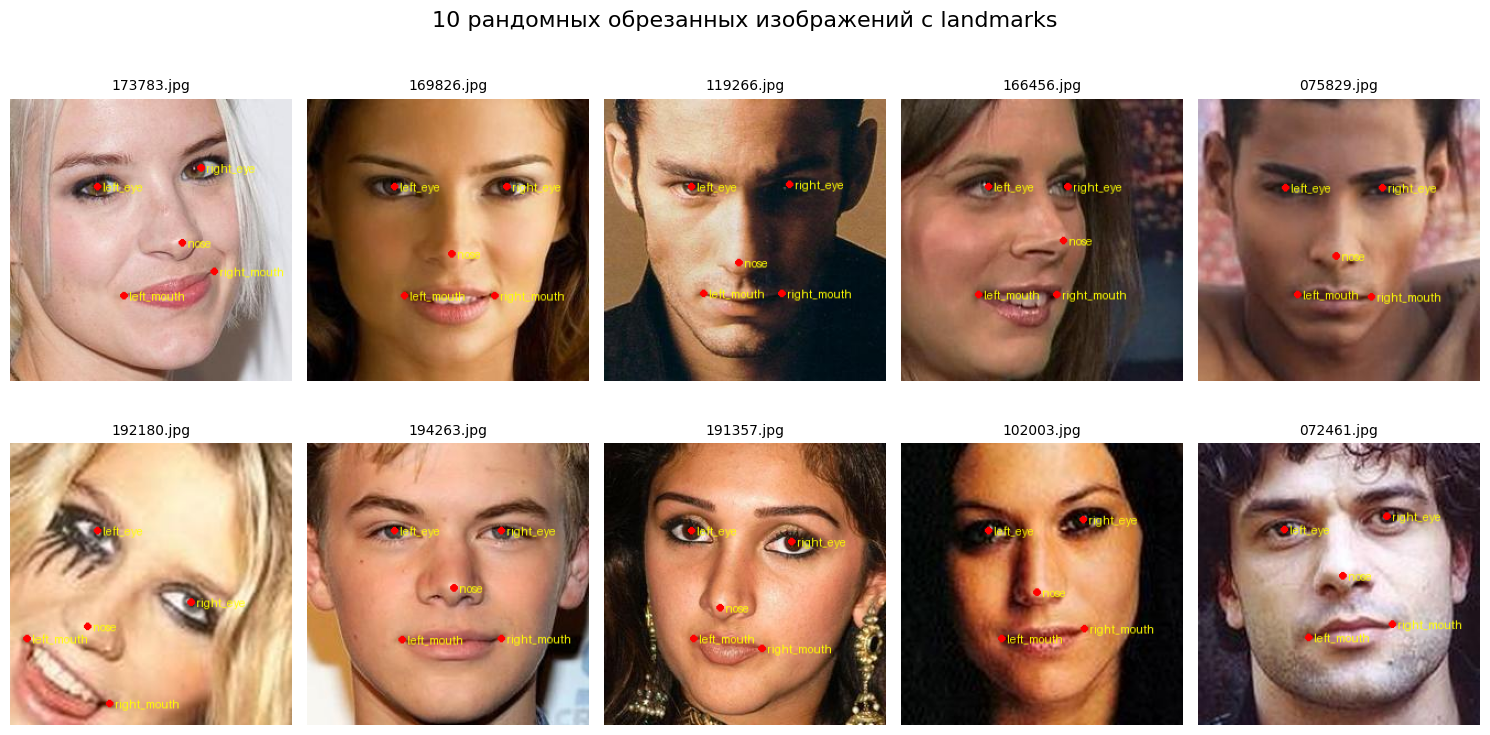

In [ ]:
from PIL import ImageDraw


# Параметры
output_dir = "/content/celeba_cropped"  # папка с обрезанными изображениями
num_samples = 10

# Выбираем 10 случайных image_id из landmarks_cropped
sample_ids = random.sample(list(landmarks_cropped['image_id']), num_samples)

# Настраиваем сетку для отображения (2 строки, 5 столбцов)
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.ravel()  # превращаем в 1D-массив для удобства

for i, image_id in enumerate(sample_ids):
    # Путь к изображению
    img_path = os.path.join(output_dir, image_id)
    if not os.path.exists(img_path):
        print(f"Не найдено: {image_id}")
        axes[i].axis('off')
        continue

    # Открываем изображение
    img = Image.open(img_path)
    draw = ImageDraw.Draw(img)

    # Находим landmarks для этого image_id
    lm_row = landmarks_cropped[landmarks_cropped['image_id'] == image_id].iloc[0]


    # Список точек для отрисовки (имя, x, y)
    points = [
        ('left_eye', lm_row['lefteye_x'], lm_row['lefteye_y']),
        ('right_eye', lm_row['righteye_x'], lm_row['righteye_y']),
        ('nose', lm_row['nose_x'], lm_row['nose_y']),
        ('left_mouth', lm_row['leftmouth_x'], lm_row['leftmouth_y']),
        ('right_mouth', lm_row['rightmouth_x'], lm_row['rightmouth_y'])
    ]

    # Рисуем точки
    for name, x, y in points:
        if pd.notna(x) and pd.notna(y):
            # Круг радиусом 3 пикселя
            draw.ellipse(
                [(x-3, y-3), (x+3, y+3)],
                outline='red', fill='red'
            )
            # Подпись
            draw.text((x+5, y-5), name, fill='yellow')


    # Отображаем в subplot
    axes[i].imshow(img)
    axes[i].set_title(image_id, fontsize=10)
    axes[i].axis('off')

# Убираем пустые подграфики
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle("10 рандомных обрезанных изображений с landmarks", fontsize=16)
plt.tight_layout()
plt.show()

Сохраняем нужные файлы:

## Подготовка датасета для обучения

На этом этапе у вас уже должен быть готовый датасет на основе CelebA In A Wild.

В разметке CelebA всего 5 точек:

1.   Левый глаз
2.   Правый глаз
3.   Нос
4.   Левый уголок рта
5.   Правый уголок рта


Единственная проблема заключается в том, что разметка - это именно точки, а не heatmap'ы. Но можно их сгенерировать самостоятельно при помощи гауссовского распределения вокруг размеченных точек. Вот вам функции в помощь. Можете их тоже редактивовать под себя, если нужно.

In [ ]:
# import numpy as np

def create_heatmap(size, landmark, sigma=2):
    """
    Создаёт один heatmap с гауссовым ядром вокруг точки.

    :param size: (height, width) — размер heatmap'а
    :param landmark:(x, y) — координаты точки
    :param sigma
    :return: heatmap массив
    """
    x, y = landmark
    h, w = size

    # Обрезаем координаты, чтобы не выйти за пределы изображения
    x = min(max(0, int(x)), w - 1)
    y = min(max(0, int(y)), h - 1)

    xx, yy = np.meshgrid(np.arange(w), np.arange(h))
    heatmap = np.exp(-((yy - y)**2 + (xx - x)**2) / (2 * sigma**2))
    return heatmap


def landmarks_to_heatmaps(image_shape, landmarks, sigma=2):
    """
    Преобразует список из N точек в набор из N heatmap'ов.

    :param image_shape: исходный размер изображения (H, W)
    :param landmarks: список из N пар координат [(x1, y1), (x2, y2), ..., (xN, yN),]
    :param sigma:
    :return: массив heatmap'ов вида [N, H, W]
    """
    heatmaps = []

    for (x, y) in landmarks:
        hm = create_heatmap(image_shape, sigma=sigma)
        heatmaps.append(hm)

    return np.array(heatmaps)

Пришлось вторую функцию немного переделать, не получалось под готовую рабочий код написать.

In [ ]:
def landmarks_to_heatmaps(image_shape, landmarks, sigma=2):
    """
    Преобразует список из N точек в N heatmap'ов.
    :param image_shape: (H, W) — размер изображения
    :param landmarks: список кортежей [(x1, y1), (x2, y2), ..., (xN, yN)]
    :param sigma: параметр размытия гауссианы
    :return: массив heatmap'ов [N, H, W]
    """
    H, W = image_shape
    N = len(landmarks)
    heatmaps = np.zeros((N, H, W))  # Инициализируем массив

    for i, (x, y) in enumerate(landmarks):
        # Передаём и размер, и координаты точки!
        heatmaps[i] = create_heatmap((H, W), (x, y), sigma)


    return heatmaps


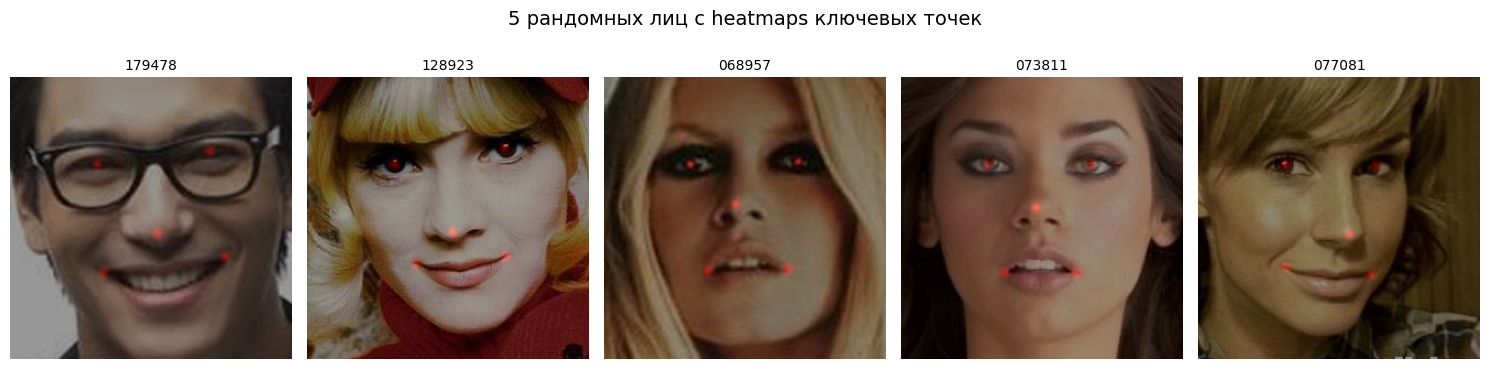

In [ ]:
num_samples = 5                                   # сколько изображений показать
sigma = 3                                       # размытие heatmap

# 5 рандомных image_id из landmarks_cropped
sample_ids = random.sample(list(landmarks_cropped['image_id']), num_samples)

# Визуализация
fig, axes = plt.subplots(1, num_samples, figsize=(15, 4))
axes = axes.ravel()

for i, image_id in enumerate(sample_ids):
    # загружаем изображение
    img_path = os.path.join(output_dir, image_id)
    if not os.path.exists(img_path):
        axes[i].set_title(f"Не найдено: {image_id}")
        axes[i].axis('off')
        continue

    img = Image.open(img_path).convert('RGB')
    img_array = np.array(img)  # [H, W, 3]
    H, W = img_array.shape[:2]

    # landmarks для выбранного image_id
    lm_row = landmarks_cropped[landmarks_cropped['image_id'] == image_id].iloc[0]
    landmarks = [
        (lm_row['lefteye_x'], lm_row['lefteye_y']),
        (lm_row['righteye_x'], lm_row['righteye_y']),
        (lm_row['nose_x'], lm_row['nose_y']),
        (lm_row['leftmouth_x'], lm_row['leftmouth_y']),
        (lm_row['rightmouth_x'], lm_row['rightmouth_y'])
    ]

    heatmaps = landmarks_to_heatmaps((H, W), landmarks, sigma=sigma)  # [5, H, W]

    # суммируем все heatmaps в один (иначе будет для каждрой точки своя хитмапа)
    combined_heatmap = np.sum(heatmaps, axis=0)  # [H, W]
    combined_heatmap /= combined_heatmap.max()  # нормируем на [0, 1]

    # Накладываем heatmap на изображение
    # Увеличиваем контраст heatmap для видимости
    heatmap_overlay = np.zeros_like(img_array)
    heatmap_overlay[:, :, 0] = (combined_heatmap * 255).astype(np.uint8)  # красный канал
    # Смешиваем с исходным изображением
    blended = np.clip(img_array * 0.6 + heatmap_overlay * 0.4, 0, 255).astype(np.uint8)

    # Отображаем
    axes[i].imshow(blended)
    axes[i].set_title(image_id.split('.')[0], fontsize=10)
    axes[i].axis('off')


plt.suptitle("5 рандомных лиц с heatmaps ключевых точек", fontsize=14)
plt.tight_layout()
plt.show()

## Сохраняем нужные файлы

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p "/content/drive/MyDrive/DLS1"

In [ ]:
# Создаём ZIP-архив
!zip -r celeba_cropped.zip /content/celeba_cropped/

# Копируем ZIP в Drive
!cp celeba_cropped.zip "/content/drive/MyDrive/DLS1/"

Выходные данные были обрезаны до нескольких последних строк (5000).
  adding: content/celeba_cropped/142880.jpg (deflated 1%)
  adding: content/celeba_cropped/074429.jpg (deflated 2%)
  adding: content/celeba_cropped/036106.jpg (deflated 1%)
  adding: content/celeba_cropped/139058.jpg (deflated 1%)
  adding: content/celeba_cropped/132316.jpg (deflated 1%)
  adding: content/celeba_cropped/179297.jpg (deflated 1%)
  adding: content/celeba_cropped/023406.jpg (deflated 3%)
  adding: content/celeba_cropped/056620.jpg (deflated 1%)
  adding: content/celeba_cropped/010168.jpg (deflated 1%)
  adding: content/celeba_cropped/101163.jpg (deflated 1%)
  adding: content/celeba_cropped/083205.jpg (deflated 1%)
  adding: content/celeba_cropped/177697.jpg (deflated 2%)
  adding: content/celeba_cropped/005264.jpg (deflated 1%)
  adding: content/celeba_cropped/096114.jpg (deflated 2%)
  adding: content/celeba_cropped/199209.jpg (deflated 1%)
  adding: content/celeba_cropped/087821.jpg (deflated 2%)
  ad

In [ ]:
folder_path = "/content/drive/MyDrive/DLS1/"

csv_filename = "attrs.csv"
csv_full_path = folder_path + csv_filename

attrs.to_csv(csv_full_path)

In [ ]:
folder_path = "/content/drive/MyDrive/DLS1/"

csv_filename = "person_id.csv"
csv_full_path = folder_path + csv_filename

person_id.to_csv(csv_full_path)

In [ ]:
folder_path = "/content/drive/MyDrive/DLS1/"

csv_filename = "landmarks_cropped.csv"
csv_full_path = folder_path + csv_filename

landmarks_cropped.to_csv(csv_full_path)

In [ ]:
# Список файлов в корне Drive
!ls "/content/drive/MyDrive/DLS1/"

# Если копировали папку — проверьте её содержимое
#!ls "/content/drive/MyDrive/DLS1/celeba_cropped/" # раскомментировать, если необходимо проверить.

attrs.csv  celeba_cropped.zip  landmarks_cropped.csv  person_id.csv


Ну вот, теперь папка с картинками и технические файлы сохранены на гугл диске, ура.

# План заданий

По итогу, в этом блоке у вас следующие задачи:

*   Подготовить датасет, сохранить файл с оригинальными названиями изображений
*   Реализовать Hourglass блок
*   Реализовать Stacked Hourglass
*   Преобразовать точки лица в Heatmap'ы
*   Обучить Stacked Hourglass
*   Найти функцию, которая по предсказанным ключевым точкам выравнивает лица на картинке (face alignment)
*   Подготовить датасет с кропнутыми и выровненными лицами для следующего этапа

**P.S. Не забывайте сохранять модели после обучения и выводите промежуточные результаты на экран**



В этой части блока я выбрала работу только с датасетом, поскольку так удобнее разделить задачи для Colab: эта часть идет полностью на CPU, не загружая GPU, а модель отправится на графический процессор.
Кроме того, удобнее иметь отдельный блокнот с фильтрацией датасета, поскольку, можно отдельно работать с ней, и потом уже передавать результат модели, а модель дорабатывать параллельно.

Таким образом, по итогам выполнения этого блокнота, у меня есть датасет, обрезанный под bbox, с рассчитанными heatmaps ключевых точек к нему. Данный датасет можно уже запускать в даталоадер и передавать мождели Stacked Hourglass для обучения предсказания тепловых карт ключевых точек. (см. part2)